# Earth2Studio: AI Weather Forecasting

This notebook demonstrates NVIDIA Earth2Studio for:
1. **2m Temperature** forecast (FCN)
2. **10m Wind Speed & MSLP** forecasts (SFNO)
3. **Hurricane Florence track comparison** (SFNO vs FCN vs ERA5 reanalysis)
4. **14-day extended range forecast** — Aurora Z500 animated GIF (Jan 2025 polar vortex)

### Prerequisites
- Python 3.12 with the `earth2` kernel
- `uv sync` (resolves all Earth2Studio extras)
- NVIDIA GPU with CUDA

---
## Imports & Config

In [1]:
import io
import os
from pathlib import Path
from datetime import datetime, timedelta

import imageio
import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import Image as IPImage
from tqdm import tqdm

os.environ["CUFILE_ENV_PATH_JSON"] = "/dev/null"

import earth2studio.run as run
from earth2studio.models.px import Aurora, FCN, SFNO
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import GFS, ARCO, WB2ERA5, NCAR_ERA5, fetch_data, prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_DIR = Path("/home/jovyan/Earth2")
os.chdir(PROJECT_DIR)

os.makedirs(PROJECT_DIR / "aifs_outputs", exist_ok=True)
os.makedirs(PROJECT_DIR / "aurora_outputs", exist_ok=True)

print(f"Device: {DEVICE}")

/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be remov

## 2m Air Temperature Forecast

In [2]:
model = FCN.load_model(FCN.load_default_package())
data = GFS()

t2m_path = PROJECT_DIR/"t2m_outputs/fcn_gfs_forecast.zarr"
backend = ZarrBackend(str(t2m_path), backend_kwargs={"overwrite": True})

backend = run.deterministic(["2026-01-08"], 10, model, data, backend)
print(backend.root.tree())

del model
torch.cuda.empty_cache()


2026-08-07 19:07:56.030 | INFO     | earth2studio.run:deterministic:87 - Running simple workflow!
2026-08-07 19:07:56.031 | INFO     | earth2studio.run:deterministic:94 - Inference device: cuda
Fetching GFS data: 100%|██████████| 26/26 [00:00<00:00, 43.28it/s]

2026-08-07 19:07:57.120 | SUCCESS  | earth2studio.run:deterministic:156 - Fetched data from GFS
2026-08-07 19:07:57.270 | INFO     | earth2studio.run:deterministic:164 - Inference starting!
Running inference: 100%|██████████| 11/11 [00:13<00:00,  1.20s/it]

2026-08-07 19:08:10.484 | SUCCESS  | earth2studio.run:deterministic:191 -
Inference complete
/
├── lat (720,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 720, 1440) float32
├── r500 (1, 11, 720, 1440) float32
├── r850 (1, 11, 720, 1440) float32
├── sp (1, 11, 720, 1440) float32
├── t250 (1, 11, 720, 1440) float32
├── t2m (1, 11, 720, 1440) float32
├── t500 (1, 11, 720, 1440) float32
├── t850 (1, 11, 720, 1440) float32
├── tcwv (1, 11, 7

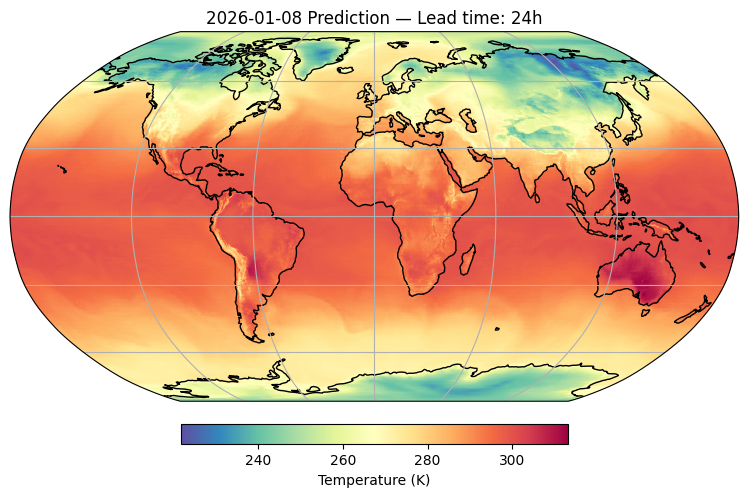

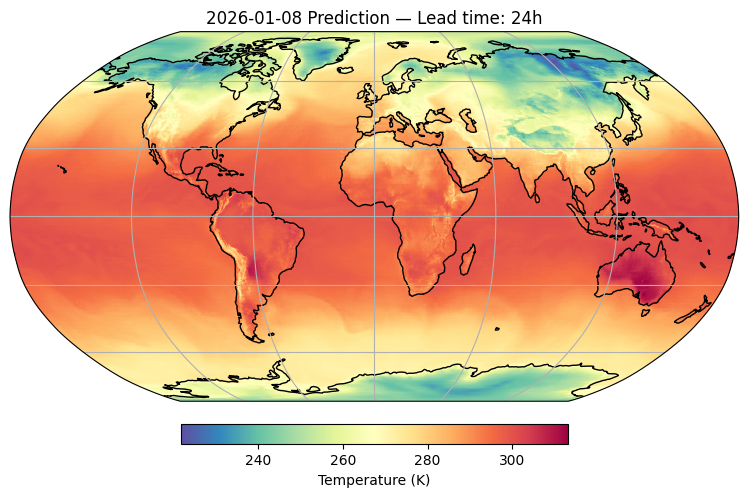

In [10]:
def plot_t2m(zarr_path, variable, step, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    projection = ccrs.Robinson()

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 6))
    im = ax.pcolormesh(
        ds["lon"], ds["lat"], ds[variable][0, step],
        transform=ccrs.PlateCarree(), cmap="Spectral_r",
    )
    plt.colorbar(
            im, 
            ax=ax, 
            orientation="horizontal", 
            pad=0.05, 
            label="Temperature (K)",
            shrink=0.5,  
            aspect=20
)

    ax.set_title(f"2026-01-08 Prediction — Lead time: {6 * step}h")
    ax.coastlines()
    ax.gridlines()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_t2m(t2m_path, "t2m", step=4, save_path=PROJECT_DIR / "t2m_outputs/t2m_prediction.jpg")

---
## 10m Wind Speed & MSLP Forecasts (SFNO)

In [4]:
sfno_model = SFNO.load_model(SFNO.load_default_package())
data = GFS()

sfno_path = PROJECT_DIR / "sfno_outputs/sfno_gfs_forecast.zarr"
sfno_path.parent.mkdir(parents=True, exist_ok=True)
backend = ZarrBackend(str(sfno_path), backend_kwargs={"overwrite": True})

backend = run.deterministic(["2026-01-01"], 10, sfno_model, data, backend)
print(backend.root.tree())

del sfno_model
torch.cuda.empty_cache()


2026-08-07 19:08:36.233 | INFO     | earth2studio.run:deterministic:87 - Running simple workflow!
2026-08-07 19:08:36.234 | INFO     | earth2studio.run:deterministic:94 - Inference device: cuda
Fetching GFS data: 100%|██████████| 73/73 [00:01<00:00, 47.08it/s]

2026-08-07 19:08:38.767 | SUCCESS  | earth2studio.run:deterministic:156 - Fetched data from GFS
2026-08-07 19:08:38.768 | INFO     | earth2studio.run:deterministic:164 - Inference starting!
Running inference: 100%|██████████| 11/11 [00:37<00:00,  3.44s/it]

2026-08-07 19:09:16.602 | SUCCESS  | earth2studio.run:deterministic:191 -
Inference complete
/
├── lat (721,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 721, 1440) float32
├── q100 (1, 11, 721, 1440) float32
├── q1000 (1, 11, 721, 1440) float32
├── q150 (1, 11, 721, 1440) float32
├── q200 (1, 11, 721, 1440) float32
├── q250 (1, 11, 721, 1440) float32
├── q300 (1, 11, 721, 1440) float32
├── q400 (1, 11, 721, 1440) float32
├── q50 (1, 11

In [5]:
def plot_sfno_10m_wind(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    ws10 = np.sqrt(ds["u10m"][0, step] ** 2 + ds["v10m"][0, step] ** 2)
    projection = ccrs.Robinson()
    levels = np.arange(0, 40, 2)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], ws10, levels,
        transform=ccrs.PlateCarree(), cmap="YlOrRd", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="10 m Wind Speed (m/s)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — 10 m Wind Speed — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()


def plot_sfno_msl(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    msl_hpa = ds["msl"][0, step] / 100.0
    projection = ccrs.Robinson()
    levels = np.arange(960, 1045, 4)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], msl_hpa, levels,
        transform=ccrs.PlateCarree(), cmap="jet", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="Mean Sea Level Pressure (hPa)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — MSLP — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

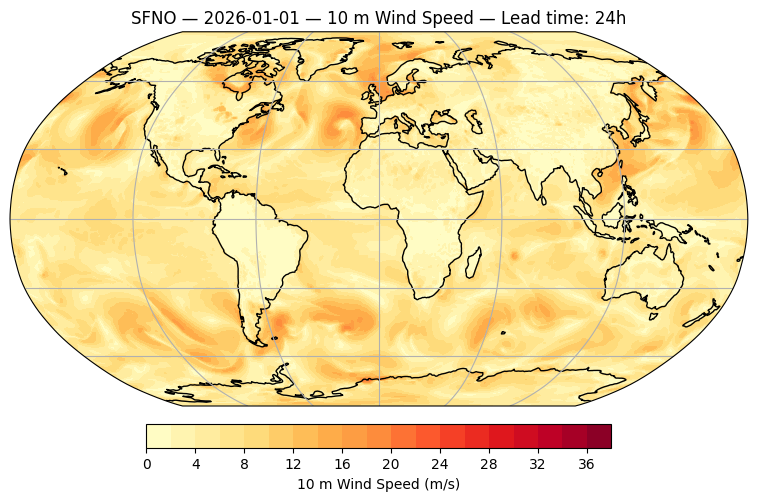

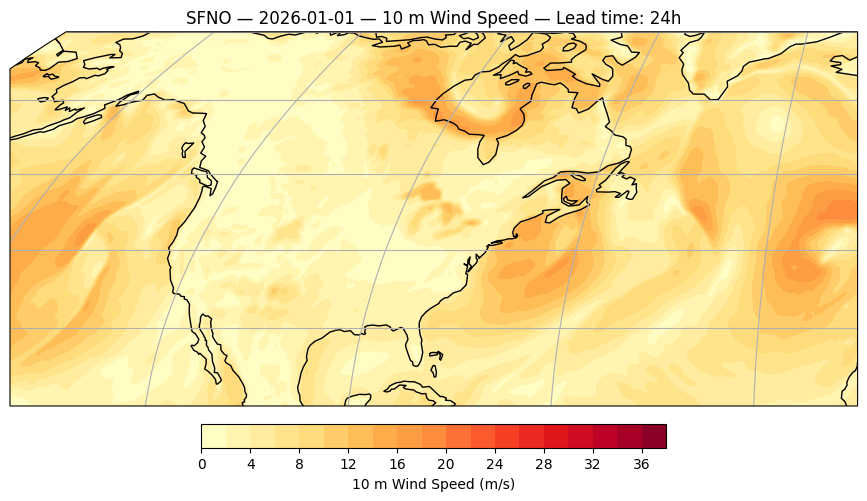

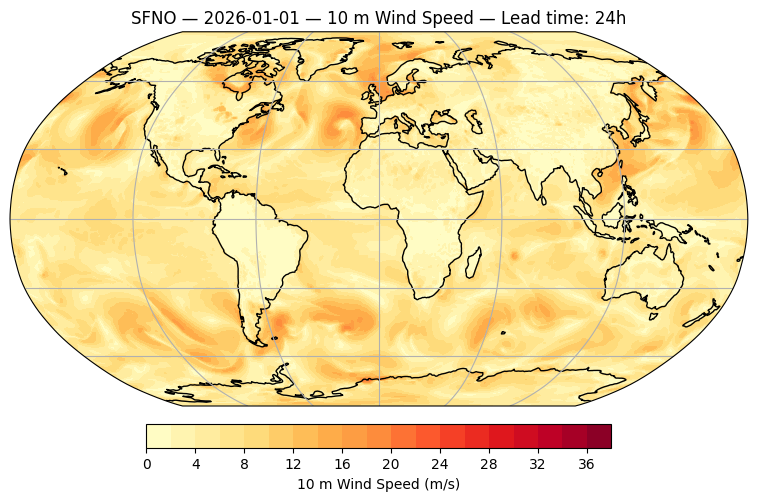

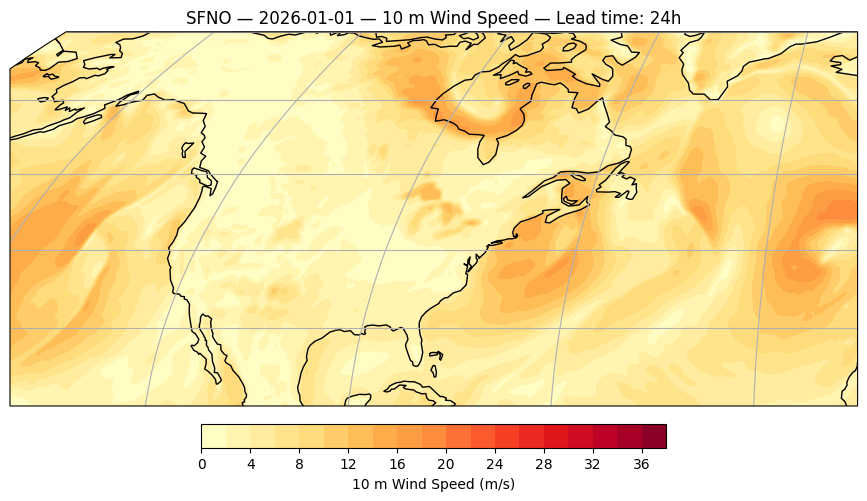

In [11]:
4# 10m wind speed
plot_sfno_10m_wind(sfno_path, step=4)
plot_sfno_10m_wind(sfno_path, step=4, extent=[220, 340, 20, 70])

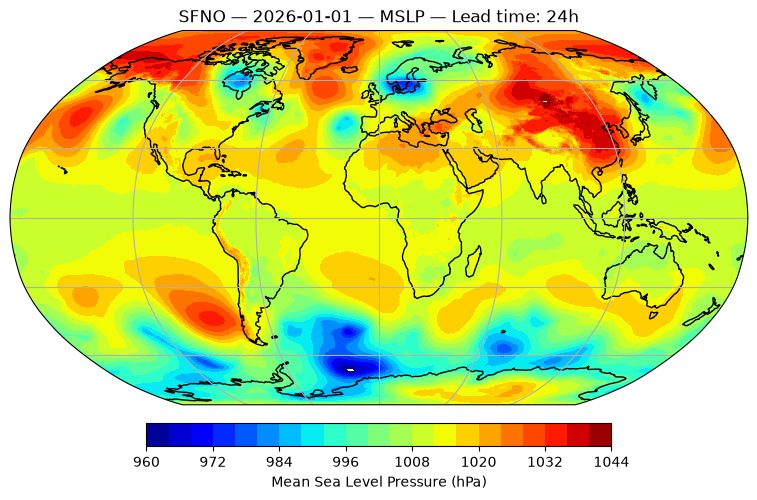

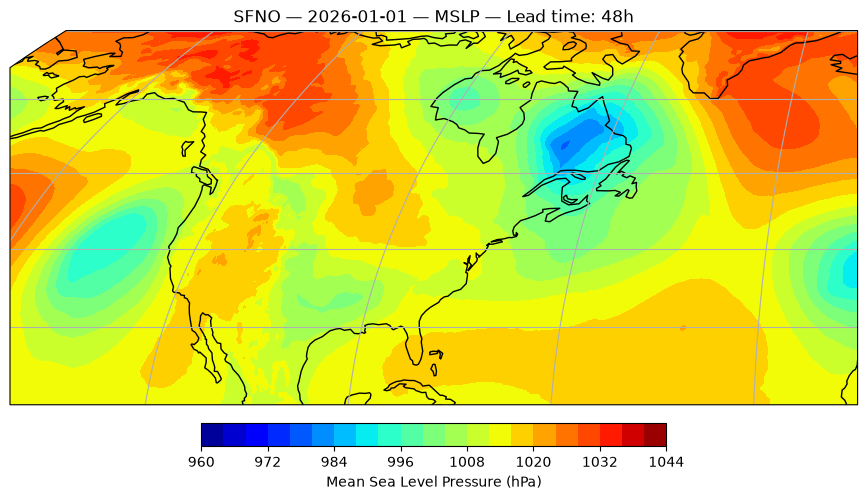

In [7]:
# Mean sea level pressure
plot_sfno_msl(sfno_path, step=4)
plot_sfno_msl(sfno_path, step=8, extent=[220, 340, 20, 70])

## Hurricane Florence Track Comparison

Compare tropical cyclone tracks from SFNO (NVIDIA), FCN (NVIDIA), and ERA5 reanalysis
for Hurricane Florence (September 2018).

In [8]:
FLORENCE_DIR = PROJECT_DIR / "florence_outputs"
FLORENCE_DIR.mkdir(exist_ok=True)

START_TIME = datetime(2018, 9, 13)
NSTEPS = 25
END_TIME = START_TIME + timedelta(hours=6 * NSTEPS)

### Inference helper

In [9]:
def run_tc_inference(prognostic, data_source, tracker, start_time, nsteps, save_path):
    """Run a prognostic model through the TC tracker and save the resulting tracks."""
    prognostic = prognostic.to(DEVICE)
    tracker.reset_path_buffer()

    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([start_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    x, coords = map_coords(x, coords, prognostic.input_coords())

    iterator = prognostic.create_iterator(x, coords)
    for step, (x, coords) in tqdm(enumerate(iterator), total=nsteps + 1):
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, _ = tracker(x, coords)
        output = output[:, 0]
        if step == nsteps:
            break

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"Saved: {save_path}")
    return tracks

### 3a — SFNO

In [10]:
sfno_florence_model = SFNO.load_model(SFNO.load_default_package())
sfno_florence_data = ARCO(cache=True)
tracker = TCTrackerWuDuan()

sfno_florence_tracks = run_tc_inference(
    sfno_florence_model, sfno_florence_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "sfno_paths.pt",
)

del sfno_florence_model
torch.cuda.empty_cache()

 96%|█████████▌| 25/26 [00:13<00:00,  1.80it/s]
Saved: /home/jovyan/Earth2/florence_outputs/sfno_paths.pt

### 3b — ERA5 Reanalysis (ground truth)

In [11]:
era5_data = WB2ERA5(cache=True, verbose=True)
tracker = TCTrackerWuDuan()
tracker.reset_path_buffer()

times = [START_TIME + timedelta(hours=6 * i) for i in range(NSTEPS + 1)]
for step, time in tqdm(enumerate(times), total=len(times)):
    da = era5_data(time, tracker.input_coords()["variable"])
    x, coords = prep_data_array(da, device=DEVICE)
    output, _ = tracker(x, coords)

era5_tracks = output.cpu()
torch.save(era5_tracks, str(FLORENCE_DIR / "era5_paths.pt"))
print("Saved ERA5 tracks")

100%|██████████| 26/26 [00:05<00:00,  4.51it/s]
Saved ERA5 tracks

### 3c — FCN

In [12]:
fcn_model = FCN.load_model(FCN.load_default_package())
fcn_data = NCAR_ERA5()
tracker = TCTrackerWuDuan()

fcn_tracks = run_tc_inference(
    fcn_model, fcn_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "fcn_paths.pt",
)

del fcn_model
torch.cuda.empty_cache()

 96%|█████████▌| 25/26 [00:04<00:00,  5.70it/s]
Saved: /home/jovyan/Earth2/florence_outputs/fcn_paths.pt

### 3d — Plot Track Comparison

In [12]:
def add_cities(ax, city_list, offset=(0.22, 0.22)):
    """Annotate cities on a cartopy axis. Each entry: (name, lat, lon[, dx, dy])."""
    text_kw = dict(
        fontsize=8, zorder=11, transform=ccrs.PlateCarree(),
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )
    for item in city_list:
        name, lat, lon = item[0], item[1], item[2]
        dx, dy = (item[3], item[4]) if len(item) == 5 else offset
        ax.plot(lon, lat, "o", color="red", markersize=3, zorder=10, transform=ccrs.PlateCarree())
        ax.text(lon + dx, lat + dy, name, **text_kw)


def plot_hurricane_tracks(models, start_time=None, end_time=None,
                          extent=(-95, -60, 30, 45), cities=None,
                          title="Tropical Cyclone Tracks", save_path=None):
    """Plot one or more TC track sets on a single map."""
    projection = ccrs.Robinson()
    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 8))

    ax.add_feature(cfeature.OCEAN, facecolor="#cfe8f3")
    ax.add_feature(cfeature.LAND, facecolor="#f2e8d5")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="#555555")
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.6, alpha=0.2)
    ax.set_extent(extent)

    for m in models:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        label_set = False
        for p in range(tracks.shape[1]):
            lats, lons = tracks[0, p, :, 0], tracks[0, p, :, 1]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() > 2:
                ax.plot(
                    lons[mask], lats[mask],
                    color=m.get("color"), linewidth=m.get("lw", 2),
                    linestyle=m.get("ls", "--"),
                    label=m["name"] if not label_set else "",
                    transform=ccrs.PlateCarree(), zorder=6,
                )
                label_set = True

    if cities:
        add_cities(ax, cities)

    if start_time and end_time:
        ax.set_title(f"{title}\n{start_time:%Y-%m-%d} to {end_time:%Y-%m-%d}")
    else:
        ax.set_title(title)

    ax.legend(loc="lower right", title="Models")
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()def add_cities(ax, city_list, offset=(0.22, 0.22)):
    """Annotate cities on a cartopy axis. Each entry: (name, lat, lon[, dx, dy])."""
    text_kw = dict(
        fontsize=8, zorder=11, transform=ccrs.PlateCarree(),
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )
    for item in city_list:
        name, lat, lon = item[0], item[1], item[2]
        dx, dy = (item[3], item[4]) if len(item) == 5 else offset
        ax.plot(lon, lat, "o", color="red", markersize=3, zorder=10, transform=ccrs.PlateCarree())
        ax.text(lon + dx, lat + dy, name, **text_kw)


def plot_hurricane_tracks(models, start_time=None, end_time=None,
                          extent=(-95, -60, 30, 45), cities=None,
                          title="Tropical Cyclone Tracks", save_path=None):
    """Plot one or more TC track sets on a single map."""
    projection = ccrs.Robinson()
    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 8))

    ax.add_feature(cfeature.OCEAN, facecolor="#cfe8f3")
    ax.add_feature(cfeature.LAND, facecolor="#f2e8d5")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="#555555")
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.6, alpha=0.2)
    ax.set_extent(extent)

    for m in models:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        label_set = False
        for p in range(tracks.shape[1]):
            lats, lons = tracks[0, p, :, 0], tracks[0, p, :, 1]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() > 2:
                ax.plot(
                    lons[mask], lats[mask],
                    color=m.get("color"), linewidth=m.get("lw", 2),
                    linestyle=m.get("ls", "--"),
                    label=m["name"] if not label_set else "",
                    transform=ccrs.PlateCarree(), zorder=6,
                )
                label_set = True

    if cities:
        add_cities(ax, cities)

    if start_time and end_time:
        ax.set_title(f"{title}\n{start_time:%Y-%m-%d} to {end_time:%Y-%m-%d}")
    else:
        ax.set_title(title)

    ax.legend(loc="lower right", title="Models")
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

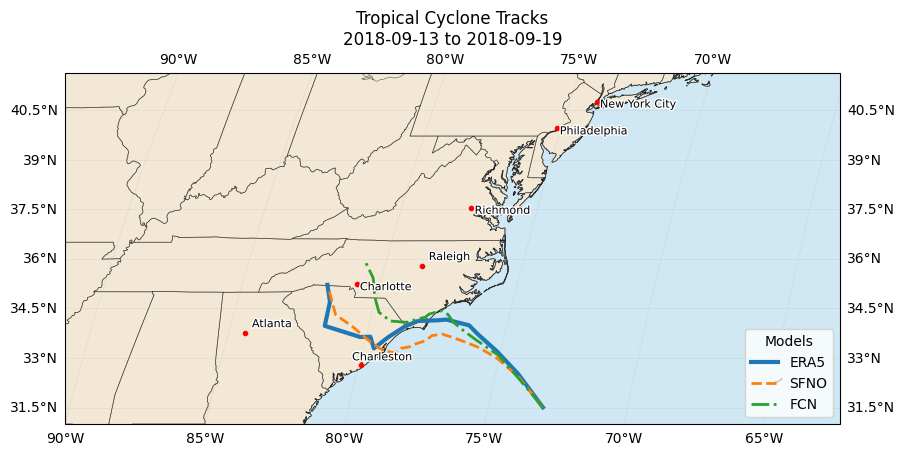

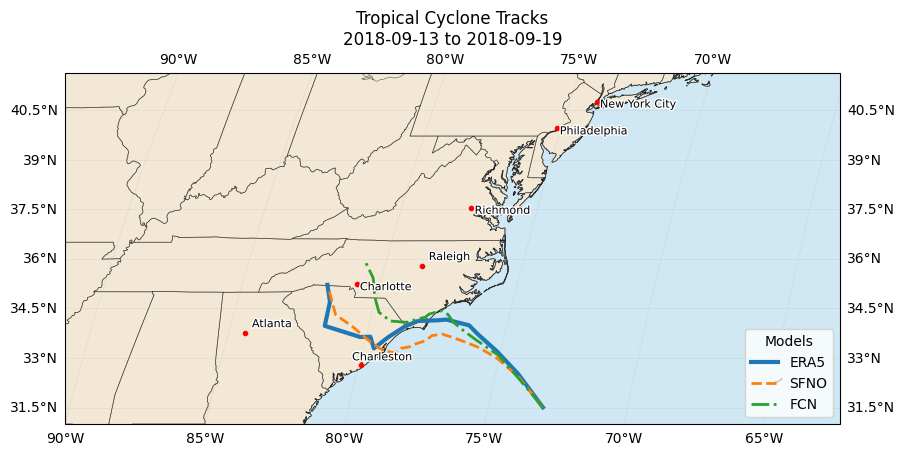

In [13]:
# Load saved tracks (or use variables from cells above)
era5_load = torch.load(FLORENCE_DIR / "era5_paths.pt", map_location="cpu")
sfno_load = torch.load(FLORENCE_DIR / "sfno_paths.pt", map_location="cpu")
fcn_load = torch.load(FLORENCE_DIR / "fcn_paths.pt", map_location="cpu")

cities = [
    ("Charlotte",    35.2271, -80.8431,  0.18, -0.18),
    ("Raleigh",      35.7796, -78.6382,  0.18,  0.18),
    ("Charleston",   32.7765, -79.9311, -0.35,  0.15),
    ("Atlanta",      33.7490, -84.3880,  0.18,  0.18),
    ("Richmond",     37.5407, -77.4360,  0.18, -0.18),
    ("Philadelphia", 39.9526, -75.1652,  0.18, -0.18),
    ("New York City", 40.7685, -73.9822,  0.18, -0.18),
]

models = [
    {"name": "ERA5",  "tracks": era5_load, "color": "#1f77b4", "lw": 3.0, "ls": "-"},
    {"name": "SFNO",  "tracks": sfno_load, "color": "#ff7f0e", "lw": 2.0, "ls": "--"},
    {"name": "FCN",   "tracks": fcn_load,  "color": "#2ca02c", "lw": 2.0, "ls": "-."},
]

plot_hurricane_tracks(
    models,
    start_time=START_TIME, end_time=END_TIME,
    extent=(-90, -65, 31, 41),
    cities=cities,
)


---
## 14-Day Extended Range Forecast: Aurora

Aurora (Microsoft, 2024) runs at 0.25° resolution with 6-hour timesteps.
Here we step it 56 times (14 days) from **January 5, 2025** — the onset of a
major polar vortex disruption — and animate the daily 500 hPa geopotential
height evolution over the Northern Hemisphere.


In [15]:
AURORA_START = "2025-01-05T00:00:00"
AURORA_STEPS = 56       # 14 days × 4 steps/day at 6h
AURORA_SAVE_EVERY = 4   # one frame per day
G = 9.80665             # m s⁻²

aurora_model = Aurora.load_model(Aurora.load_default_package())
aurora_model = aurora_model.to(DEVICE).eval()

gfs_source = GFS()
time_array = to_time_array([AURORA_START])
x, coords = fetch_data(
    source=gfs_source,
    time=time_array,
    variable=aurora_model.input_coords()["variable"],
    lead_time=aurora_model.input_coords()["lead_time"],
    device=DEVICE,
)
x, coords = map_coords(x, coords, aurora_model.input_coords())

z500_frames, frame_labels = [], []

iterator = aurora_model.create_iterator(x, coords)
for step, (x, coords) in tqdm(enumerate(iterator), total=AURORA_STEPS, desc="Aurora 14-day forecast"):
    if (step + 1) % AURORA_SAVE_EVERY == 0:
        var_list = list(coords["variable"])
        z_idx = var_list.index("z500")
        z500_frames.append(x[0, 0, z_idx].cpu().numpy())
        day = (step + 1) // AURORA_SAVE_EVERY
        valid = np.datetime64(AURORA_START) + np.timedelta64(day, "D")
        frame_labels.append(f"Day +{day}  ({str(valid)[:10]})") 
    if step + 1 >= AURORA_STEPS:
        break

print(f"Collected {len(z500_frames)} daily frames.")

del aurora_model
torch.cuda.empty_cache()

Aurora 14-day forecast:  98%|█████████▊| 55/56 [05:10<00:05,  5.65s/it]
Collected 14 daily frames.

Saved: /home/jovyan/Earth2/aurora_outputs/aurora_z500_nh_14day.gif

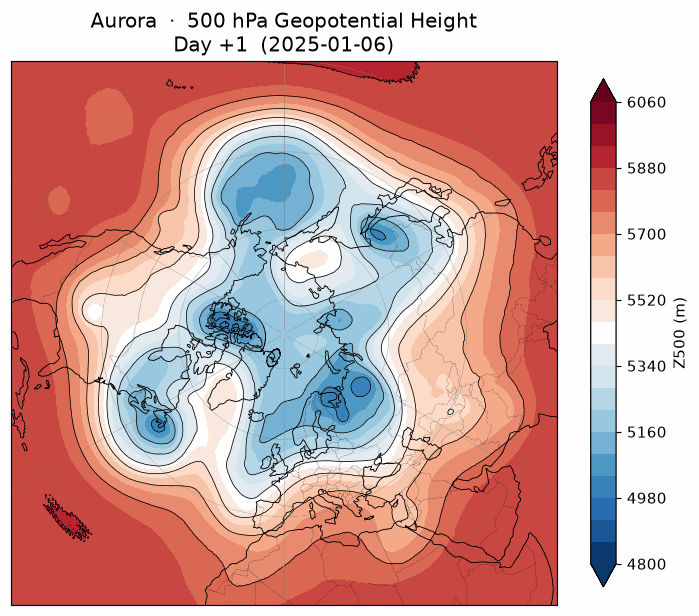

In [16]:
lats = np.asarray(coords["lat"])
lons = np.asarray(coords["lon"])

proj = ccrs.NorthPolarStereo()
frames_png = []

for z500, label in zip(z500_frames, frame_labels):
    z_height = z500 / G  # geopotential (m²/s²) → geopotential height (m)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={"projection": proj})
    ax.set_extent([-180, 180, 20, 90], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax.gridlines(draw_labels=False, linewidth=0.4, color="gray", alpha=0.5)

    levels = np.arange(4800, 6100, 60)
    cf = ax.contourf(
        lons, lats, z_height, levels=levels,
        cmap="RdBu_r", transform=ccrs.PlateCarree(), extend="both",
    )
    ax.contour(
        lons, lats, z_height, levels=np.arange(4800, 6100, 120),
        colors="black", linewidths=0.5, transform=ccrs.PlateCarree(),
    )

    plt.colorbar(cf, ax=ax, label="Z500 (m)", shrink=0.75, pad=0.05)
    ax.set_title(f"Aurora  ·  500 hPa Geopotential Height\n{label}", fontsize=13)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    buf.seek(0)
    frames_png.append(imageio.v2.imread(buf))
    plt.close(fig)

gif_path = PROJECT_DIR / "aurora_outputs/aurora_z500_nh_14day.gif"
imageio.mimsave(str(gif_path), frames_png, fps=2, loop=0)
print(f"Saved: {gif_path}")
IPImage(str(gif_path))